In [1]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.patches import Patch

os.environ["TZ"] = "Europe/Berlin"
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

In [2]:
BASE = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune"
OUT_DIR = f"{BASE}/results/09_HIHAtlas"
adata = sc.read_h5ad(f"{BASE}/data/03_HIHAtlas/HIHAtlas_ds_TICAannot_tmin2.h5ad")
print(adata)


AnnData object with n_obs × n_vars = 129435 × 32338
    obs: 'cohort.cohortGuid', 'sample.sampleKitGuid', 'specimen.specimenGuid', 'pipeline.fileGuid', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.ageGroup', 'subject.race', 'subject.ethnicity', 'subject.cmv', 'subject.bmi', 'sample.visitName', 'sample.drawYear', 'sample.subjectAgeAtDraw', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'original_barcodes', 'cell_name', 'n_reads', 'n_umis', 'n_genes', 'total_counts_mito', 'pct_counts_mito', 'doublet_score', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'suspension_type', 'assay_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'decoupler_level1_celltype', 'decoupler_level

### UMAP HIHAtlas Level 1

In [3]:
counts = adata.obs['decoupler_level1_celltype'].value_counts(dropna=False)
print(counts)
print("Categories with 0 cells:")
print(counts[counts == 0])

decoupler_level1_celltype
B cells                     12006
T cells regulatory          11321
Monocytes                   10528
T cells naive               10311
NK                          10016
pDC                          8738
CD4 naive-memory             6389
CD8 cytotoxic                6346
CD4 transitional memory      6090
CD4 effector memory          5795
T cells proliferative        5160
Plasma B cells               4909
CD8 effector memory          4432
Macro. and mono. prolif.     4067
T helper cells               3718
CD8 pre-exhausted            3433
CD4 recently activated       3112
CD8 terminally exhausted     2651
B cells proliferative        2437
cDC                          2292
mDC                          1921
TAMs proinflammatory         1911
TAMs C1QC                    1852
Name: count, dtype: int64
Categories with 0 cells:
Series([], Name: count, dtype: int64)


In [4]:
# Alle erwarteten Kategorien
expected = sorted(adata.obs["decoupler_level1_celltype"].cat.categories)
actual = sorted(adata.obs["decoupler_level1_celltype"].unique())

checkpoint(f"Expected: {len(expected)}")
checkpoint(f"Actual: {len(actual)}")
checkpoint(f"Missing: {set(expected) - set(actual)}")

[2026-09-30 20:38:15] Expected: 23
[2026-09-30 20:38:15] Actual: 23
[2026-09-30 20:38:15] Missing: set()


In [5]:
from matplotlib.colors import to_hex
import itertools
from fractions import Fraction
import colorsys

In [20]:
# ── Helper functions ─────────────────────────────────────────────────────────────────────
def fracs():
    """Generate fractions for distinct hues."""
    yield Fraction(0)
    for k in range(20):
        denom = 2**k
        for j in range(1, denom, 2):
            yield Fraction(j, denom)

def hsv_to_rgb(x):
    """Convert HSV to RGB."""
    return colorsys.hsv_to_rgb(*map(float, x))

def rgbs():
    """Generate visually distinct RGB colors."""
    for h in fracs():
        for s in [Fraction(6, 10)]:
            for v in [Fraction(8, 10), Fraction(5, 10)]:
                yield hsv_to_rgb((h, s, v))


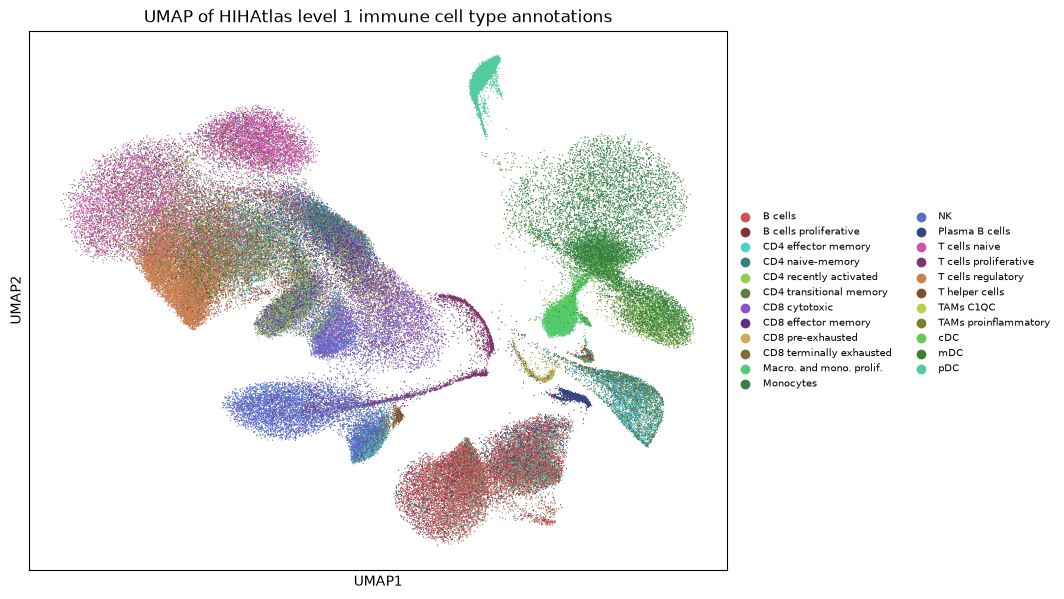

[2026-09-04 15:05:48] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_04_umap_hiha_level1_3.pdf


In [21]:
fig, ax = plt.subplots(figsize=(9, 7))

# Generate 25 visually distinct colors
n_categories = 25
colors = list(itertools.islice(rgbs(), n_categories))
palette = [to_hex(c) for c in colors]

sc.pl.umap(adata, color="decoupler_level1_celltype", palette=palette, ax=ax, show=False, size=3, legend_fontsize=7, title="UMAP of HIHAtlas level 1 immune cell type annotations")
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "09_04_umap_hiha_level1_3.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

In [5]:
celltype_palette = {
    "B cells":                     "#5A5156",
    "B cells proliferative":       "#E4E1E3",
    "Plasma B cells":              "#F6222E",
    "T cells naive":               "#FE00FA",
    "T cells regulatory":          "#16FF32",
    "T helper cells":              "#3283FE",
    "CD4 effector memory":         "#FEAF16",
    "T cells proliferative":       "#B00068",
    "CD4 recently activated":      "#1CFFCE",
    "CD4 naive-memory":            "#90AD1C",
    "CD4 transitional memory":     "#2ED9FF",
    "CD8 pre-exhausted":           "#DEA0FD",
    "CD8 cytotoxic":               "#AA0DFE",
    "CD8 effector memory":         "#F8A19F",
    "CD8 terminally exhausted":    "#325A9B",
    "NK":                          "#C4451C",
    # "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
    "cDC":                         "#822E1C",
    "pDC":                         "#333333",
    "mDC":                         "#F7E1A0",
    # "Mast cells":                  "#C075A6",
}

current_cats = set(adata.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
adata.obs["decoupler_level1_celltype"] = adata.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))

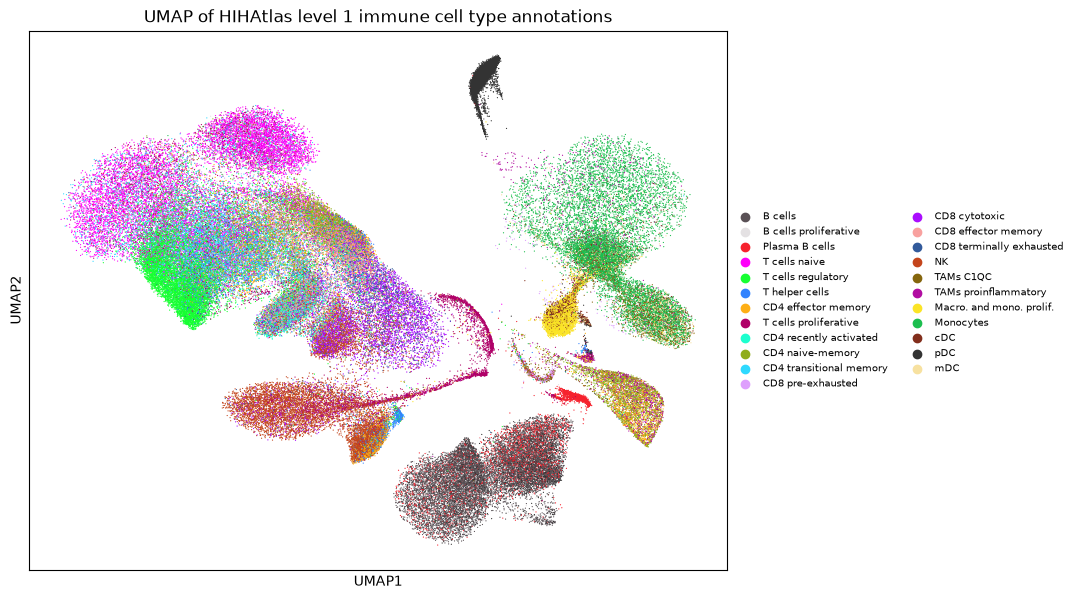

[2026-09-12 11:21:08] UMAP saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_04_umap_hiha_level1_4.pdf


In [6]:

fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(adata, color="decoupler_level1_celltype", ax=ax, show=False, palette=celltype_palette, size=3, legend_fontsize=7, title="UMAP of HIHAtlas level 1 immune cell type annotations")
ax.set_rasterized(True)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=2, frameon=False, fontsize=7)
out_umap = os.path.join(OUT_DIR, "09_04_umap_hiha_level1_4.pdf")
plt.savefig(out_umap, bbox_inches="tight", dpi=300)
plt.show(fig)
plt.close(fig)
checkpoint(f"UMAP saved: {out_umap}")

#### UMAP grid: one subplot per decoupler_level1_celltype (20 celltypes total)

[2026-09-12 11:33:12] Celltypes (23): ['B cells', 'B cells proliferative', 'CD4 effector memory', 'CD4 naive-memory', 'CD4 recently activated', 'CD4 transitional memory', 'CD8 cytotoxic', 'CD8 effector memory', 'CD8 pre-exhausted', 'CD8 terminally exhausted', 'Macro. and mono. prolif.', 'Monocytes', 'NK', 'Plasma B cells', 'T cells naive', 'T cells proliferative', 'T cells regulatory', 'T helper cells', 'TAMs C1QC', 'TAMs proinflammatory', 'cDC', 'mDC', 'pDC']
[2026-09-12 11:33:12] Generated 23 colors
[2026-09-12 11:33:12] Plotting 23 celltypes in 5×5 grid...
[2026-09-12 11:33:35] Saving grid to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_04_umap_hiha_level1_grid4.pdf...
[2026-09-12 11:33:38] Saved: /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_04_umap_hiha_level1_grid4.pdf


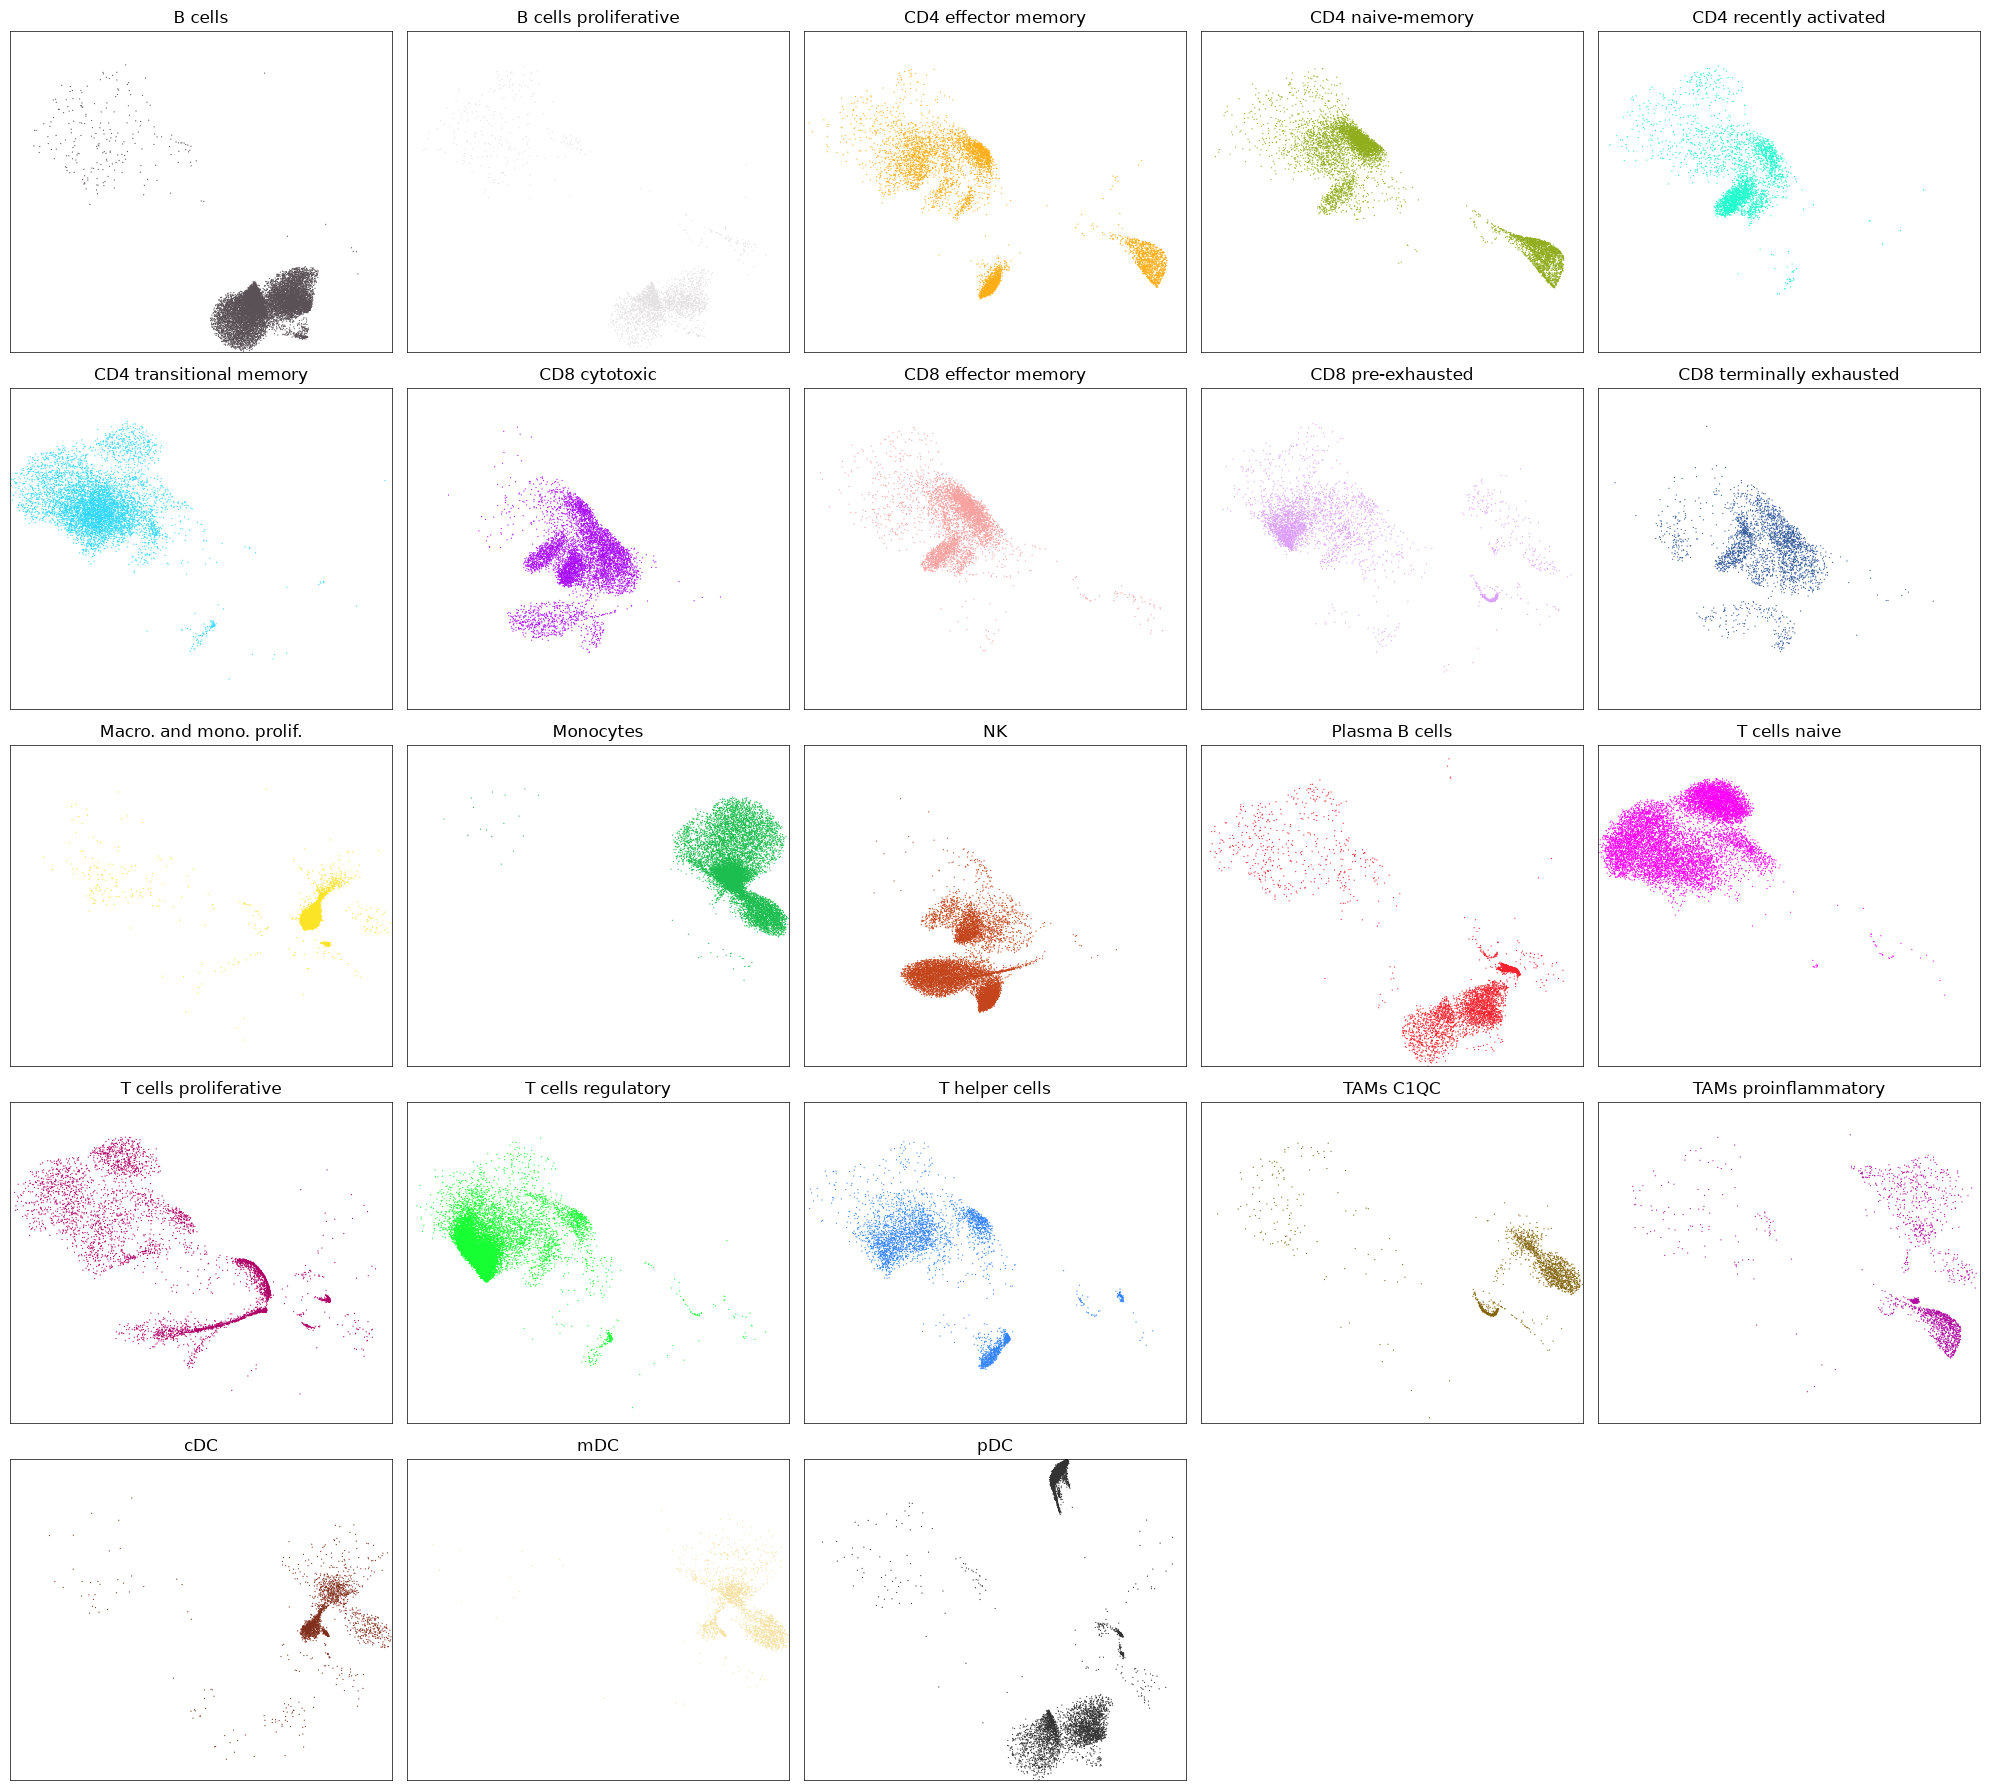

[2026-09-12 11:33:39] Done!


In [15]:
# ── Get celltypes and generate consistent palette ────────────────────────────────────────
celltype_col = "decoupler_level1_celltype"
celltypes = sorted(adata.obs[celltype_col].unique())
n_celltypes = len(celltypes)

checkpoint(f"Celltypes ({n_celltypes}): {celltypes}")

# Generate consistent palette (same as single UMAP plot)
import itertools
from fractions import Fraction
import colorsys
from matplotlib.colors import to_hex

def fracs():
    yield Fraction(0)
    for k in range(20):
        denom = 2**k
        for j in range(1, denom, 2):
            yield Fraction(j, denom)

def hsv_to_rgb(x):
    return colorsys.hsv_to_rgb(*map(float, x))

def rgbs():
    for h in fracs():
        for s in [Fraction(6, 10)]:
            for v in [Fraction(8, 10), Fraction(5, 10)]:
                yield hsv_to_rgb((h, s, v))

palette = [to_hex(c) for c in itertools.islice(rgbs(), n_celltypes)]
checkpoint(f"Generated {len(palette)} colors")

# ── Plot grid ────────────────────────────────────────────────────────────────────────────
# Grid layout: 4 rows × 5 columns = 20 subplots
n_cols = 5
n_rows = (n_celltypes + n_cols - 1) // n_cols  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 18))
axes = axes.flatten()

checkpoint(f"Plotting {n_celltypes} celltypes in {n_rows}×{n_cols} grid...")
all_umap = adata.obsm["X_umap"]

xlim = (all_umap[:, 0].min(), all_umap[:, 0].max())
ylim = (all_umap[:, 1].min(), all_umap[:, 1].max())

for i, celltype in enumerate(celltypes):
    ax = axes[i]
    
    # Subset to current celltype
    mask = adata.obs[celltype_col] == celltype
    adata_subset = adata[mask].copy()
    
    # Plot UMAP
    sc.pl.umap(
        adata_subset,
        color=celltype_col,
        ax=ax,
        show=False,
        size=3,
        legend_loc=None,  # no legend in individual plots
        frameon=True,
        title=celltype
    )
    
    # frame for each umap plot
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
  
    
    # squared axis and visible frame
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('auto')  # quadratisch

    for spine_name in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine_name].set_visible(True)
        ax.spines[spine_name].set_linewidth(0.5)
        ax.spines[spine_name].set_color('black')

# Hide empty subplots (if any)
for j in range(n_celltypes, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()


# ── Save ─────────────────────────────────────────────────────────────────────────────────
out_pdf = os.path.join(OUT_DIR, "09_04_umap_hiha_level1_grid4.pdf")
checkpoint(f"Saving grid to {out_pdf}...")
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
checkpoint(f"Saved: {out_pdf}")
plt.show(fig)
plt.close(fig)
checkpoint("Done!")

### UMAP MP scores grid

In [6]:
import re

In [24]:
mp_scores = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_03_nmf_downsampled/mp_scores_healthy.csv", index_col=0)


In [25]:
# barcode suffix mismatch -> use intersection instead of direct .loc
common_barcodes = mp_scores.index.intersection(adata.obs_names)
n_missing = adata.n_obs - len(common_barcodes)
checkpoint(f"{len(common_barcodes)} / {adata.n_obs} adata cells matched to mp_scores "
           f"({n_missing} missing)")

[2026-09-30 20:55:26] 129435 / 129435 adata cells matched to mp_scores (0 missing)


In [51]:
# align to adata.obs_names order; unmatched cells become NaN
mp_scores_aligned = mp_scores.reindex(adata.obs_names)

def mp_sort_key(name):
    m = re.search(r"(\d+)", name)
    return int(m.group(1)) if m else 0

ALL_MPS = sorted(mp_scores.columns.tolist(), key=mp_sort_key)

for mp in ALL_MPS:
    adata.obs[mp] = mp_scores_aligned[mp].values


In [27]:
SELECTED_MPS = ['MP1_score',
 'MP2_score',
 'MP3_score',
 'MP4_score',
 'MP5_score',
 'MP6_score',
 'MP7_score']

[2026-09-30 20:52:37] Plotting UMAPs
[2026-09-30 20:52:37] Plotted MP1_score
[2026-09-30 20:52:37] Plotted MP2_score
[2026-09-30 20:52:37] Plotted MP3_score
[2026-09-30 20:52:37] Plotted MP4_score
[2026-09-30 20:52:38] Plotted MP5_score
[2026-09-30 20:52:38] Plotted MP6_score
[2026-09-30 20:52:38] Plotted MP7_score


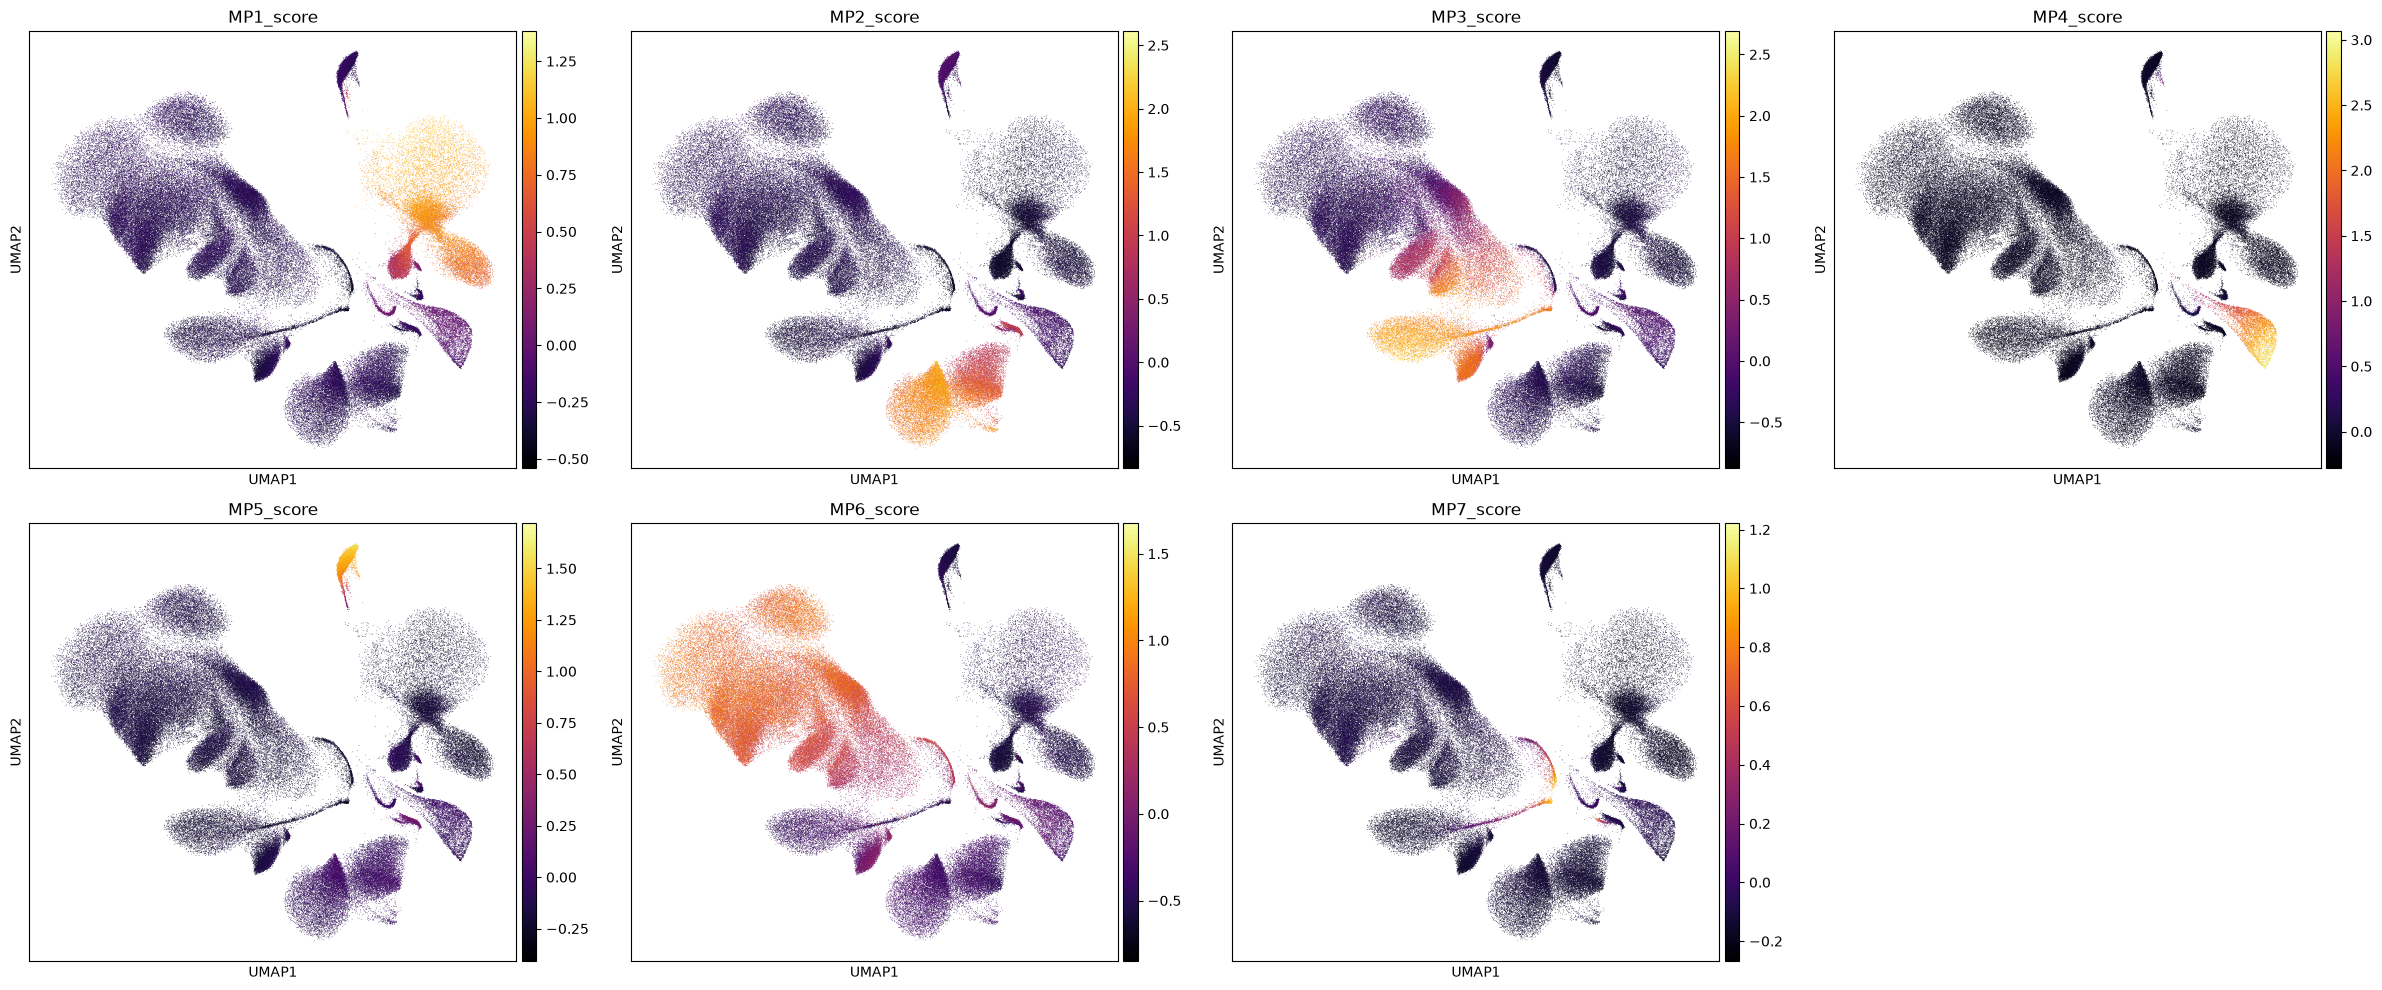

[2026-09-30 20:52:50] PDF saved


In [ ]:

checkpoint("Plotting UMAPs")
n_cols = 4
n_rows = -(-len(ALL_MPS) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
axes = axes.flatten()

for i, mp in enumerate(ALL_MPS):
    if mp in adata.obs.columns:
        sc.pl.umap(adata, color=mp, color_map="inferno", show=False, ax=axes[i], title=mp)
        axes[i].set_rasterized(True)
        checkpoint(f"Plotted {mp}")
    else:
        checkpoint(f"SKIPPED {mp} (not in adata.obs)")

# Hide empty subplots
for j in range(len(ALL_MPS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_04_umap_grid_selectMP_HIHA.pdf"), bbox_inches="tight", dpi=300)
plt.show()
plt.close()
checkpoint("PDF saved")

### UMAP cells assigned to MP

In [52]:
MIN_OVERLAP = 0.5  # minimum fraction of an MP's genes that must be present to score it
PERCENTILE_THRESHOLD = 75  

In [53]:
MP_PALETTE_HIHA_ALT = {
    "MP1": "#0caece",  # 
    "MP2": "#946da1",  # 
    "MP3": "#90e0ef",  # 
    "MP4": "#00c39f",  # 
    "MP5": "#655fdc",  # 
    "MP6": "#4cd276",  # 
    "MP7": "#6B157A",  # 
    "MP8": "#939393",  # 
}

In [54]:
scored_mask = adata.obs[ALL_MPS].notna().any(axis=1)
scores_df = adata.obs.loc[scored_mask, ALL_MPS]
 
thresholds = {mp: scores_df[mp].quantile(PERCENTILE_THRESHOLD / 100) for mp in ALL_MPS}
checkpoint(f"Per-MP {PERCENTILE_THRESHOLD}th percentile thresholds: {thresholds}")
 
argmax_mp = scores_df.idxmax(axis=1)
 
passes_threshold = pd.Series(False, index=scores_df.index)
for mp in ALL_MPS:
    is_this_mp = argmax_mp == mp
    passes_threshold |= is_this_mp & (scores_df[mp] >= thresholds[mp])
 
dominant_mp = pd.Series("Not scored", index=adata.obs_names, dtype=object)
dominant_mp.loc[scores_df.index] = "Other"

assigned_bare = argmax_mp[passes_threshold].str.replace("_score", "", regex=False)
dominant_mp.loc[scores_df.index[passes_threshold]] = assigned_bare.values
 
mp_order_all = [mp.replace("_score", "") for mp in ALL_MPS]
mp_order = [mp for mp in MP_PALETTE_HIHA_ALT if mp in mp_order_all]
adata.obs["dominant_MP"] = pd.Categorical(
    dominant_mp, categories=["Other"] + mp_order
)


[2026-09-30 21:17:07] Per-MP 75th percentile thresholds: {'MP1_score': np.float64(-0.2104294815578976), 'MP2_score': np.float64(-0.2688901713001876), 'MP3_score': np.float64(0.0233597787221273), 'MP4_score': np.float64(-0.0681519120401759), 'MP5_score': np.float64(-0.11368898559683965), 'MP6_score': np.float64(0.6260554440816243), 'MP7_score': np.float64(-0.1085737705466506), 'MP8_score': np.float64(0.2672097134217476)}


In [55]:
valid_labels = {"Not scored", "Other"} | set(mp_order)
n_reassigned = (~dominant_mp.isin(valid_labels)).sum()
if n_reassigned:
    reassigned_values = sorted(set(dominant_mp[~dominant_mp.isin(valid_labels)]))
    checkpoint(f"{n_reassigned} cells assigned to an MP not in mp_order "
               f"({reassigned_values}) - moving them to 'Other'")
    dominant_mp = dominant_mp.where(dominant_mp.isin(valid_labels), "Other")
 
adata.obs["dominant_MP"] = pd.Categorical(
    dominant_mp, categories=["Not scored", "Other"] + mp_order
)
checkpoint("Dominant MP assignment counts:")
print(adata.obs["dominant_MP"].value_counts(dropna=False))

[2026-09-30 21:17:09] Dominant MP assignment counts:
dominant_MP
MP6           31771
MP3           24326
MP2           21304
Other         20678
MP1           18572
MP5            5061
MP4            4822
MP8            2171
MP7             730
Not scored        0
Name: count, dtype: int64


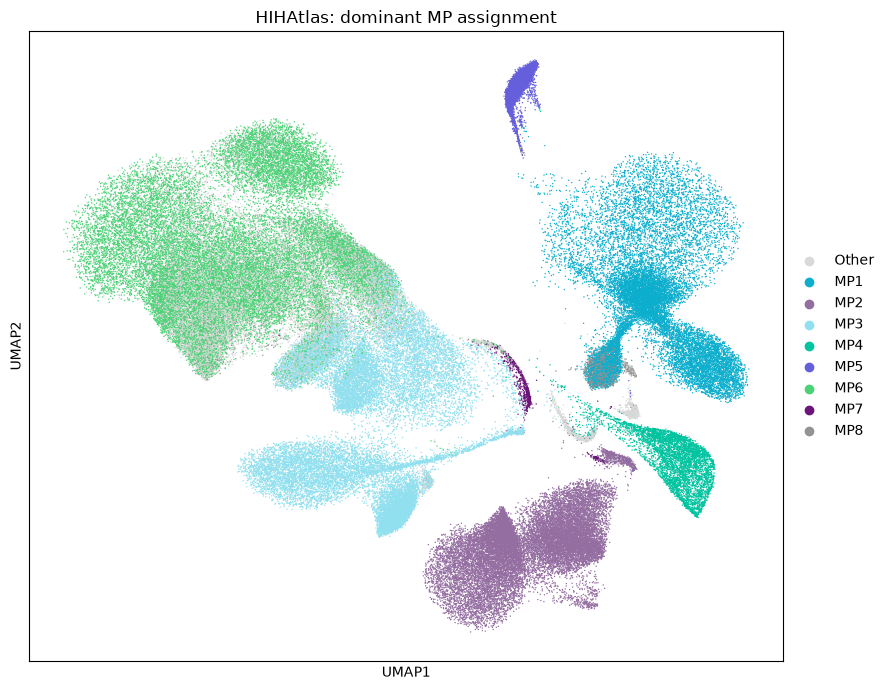

[2026-09-30 21:17:15] Saved UMAP to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/09_HIHAtlas/09_04_umap_hiha_all_MP.pdf


In [56]:
adata.obs["dominant_MP"] = adata.obs["dominant_MP"].cat.remove_unused_categories()

palette = {"Other": "#D9D9D9",
           **{mp: MP_PALETTE_HIHA_ALT[mp] for mp in mp_order}}
adata.uns["dominant_MP_colors"] = [palette[c] for c in adata.obs["dominant_MP"].cat.categories]
 
fig, ax = plt.subplots(figsize=(9, 7))
sc.pl.umap(
    adata,
    color="dominant_MP",
    ax=ax,
    show=False,
    size=4,
    title="HIHAtlas: dominant MP assignment",
)
fig.tight_layout()
 
out_pdf = os.path.join(OUT_DIR, "09_04_umap_hiha_all_MP.pdf")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show(fig)
plt.close(fig)
checkpoint(f"Saved UMAP to {out_pdf}")

In [44]:
print("\nRaw dominant_mp value counts (before Categorical):")
print(dominant_mp.value_counts(dropna=False))
print(f"mp_order (valid MP categories): {mp_order}")
 
adata.obs["dominant_MP"] = pd.Categorical(
    dominant_mp, categories=["Not scored", "Other"] + mp_order
)
n_na = adata.obs["dominant_MP"].isna().sum()
checkpoint(f"{n_na} of {adata.n_obs} cells are NaN in dominant_MP after Categorical conversion")
if n_na:
    dropped_values = sorted(set(dominant_mp[adata.obs["dominant_MP"].isna()]))
    print(f"Raw values that didn't match any category: {dropped_values}")
 
checkpoint("Dominant MP assignment counts:")
print(adata.obs["dominant_MP"].value_counts(dropna=False))


Raw dominant_mp value counts (before Categorical):
MP6      31771
MP3      24326
MP2      21304
Other    20678
MP1      18572
MP5       5061
MP4       4822
MP8       2171
MP7        730
Name: count, dtype: int64
mp_order (valid MP categories): ['MP1', 'MP2', 'MP3', 'MP4', 'MP5', 'MP6', 'MP7']
[2026-09-30 21:09:22] 2171 of 129435 cells are NaN in dominant_MP after Categorical conversion
Raw values that didn't match any category: ['MP8']
[2026-09-30 21:09:22] Dominant MP assignment counts:
dominant_MP
MP6           31771
MP3           24326
MP2           21304
Other         20678
MP1           18572
MP5            5061
MP4            4822
NaN            2171
MP7             730
Not scored        0
Name: count, dtype: int64


### Stacked barplot: number of celltypes in HIHAtlas and GBmap

In [3]:
adata_gbmap = sc.read_h5ad(f"{BASE}/data/01_extGBmap/immune_cells_gbmap_TICAannot_gpu.h5ad")

In [8]:
celltype_palette = {
    "B cells":                     "#5A5156",
    "B cells proliferative":       "#E4E1E3",
    "Plasma B cells":              "#F6222E",
    "T cells naive":               "#FE00FA",
    "T cells regulatory":          "#16FF32",
    "T helper cells":              "#3283FE",
    "CD4 effector memory":         "#FEAF16",
    "T cells proliferative":       "#B00068",
    "CD4 recently activated":      "#1CFFCE",
    "CD4 naive-memory":            "#90AD1C",
    "CD4 transitional memory":     "#2ED9FF",
    "CD8 pre-exhausted":           "#DEA0FD",
    "CD8 cytotoxic":               "#AA0DFE",
    "CD8 effector memory":         "#F8A19F",
    "CD8 terminally exhausted":    "#325A9B",
    "NK":                          "#C4451C",
    "Macrophages SPP1":            "#1C8356",
    "TAMs C1QC":                   "#85660D",
    "TAMs proinflammatory":        "#B10DA1",
    "Macro. and mono. prolif.":    "#FBE426",
    "Monocytes":                   "#1CBE4F",
    "cDC":                         "#822E1C",
    "pDC":                         "#333333",
    "mDC":                         "#F7E1A0",
    "Mast cells":                  "#C075A6",
}
current_cats_gb = set(adata_gbmap.obs["decoupler_level1_celltype"].cat.categories)
assert set(celltype_palette.keys()) == current_cats_gb, (
    f"Mismatch — missing: {current_cats - set(celltype_palette.keys())}, "
    f"extra: {set(celltype_palette.keys()) - current_cats}"
)
adata_gbmap.obs["decoupler_level1_celltype"] = adata_gbmap.obs["decoupler_level1_celltype"].cat.reorder_categories(list(celltype_palette.keys()))

In [13]:
counts_gbmap = adata_gbmap.obs["decoupler_level1_celltype"].value_counts()
counts_hiha = adata.obs["decoupler_level1_celltype"].value_counts()

props_df = pd.DataFrame({
    "GBmap": counts_gbmap,
    "HIHA": counts_hiha,
})
props_df = props_df.reindex(celltype_palette.keys()).fillna(0)

props_pct = props_df.div(props_df.sum(axis=0), axis=1) * 100


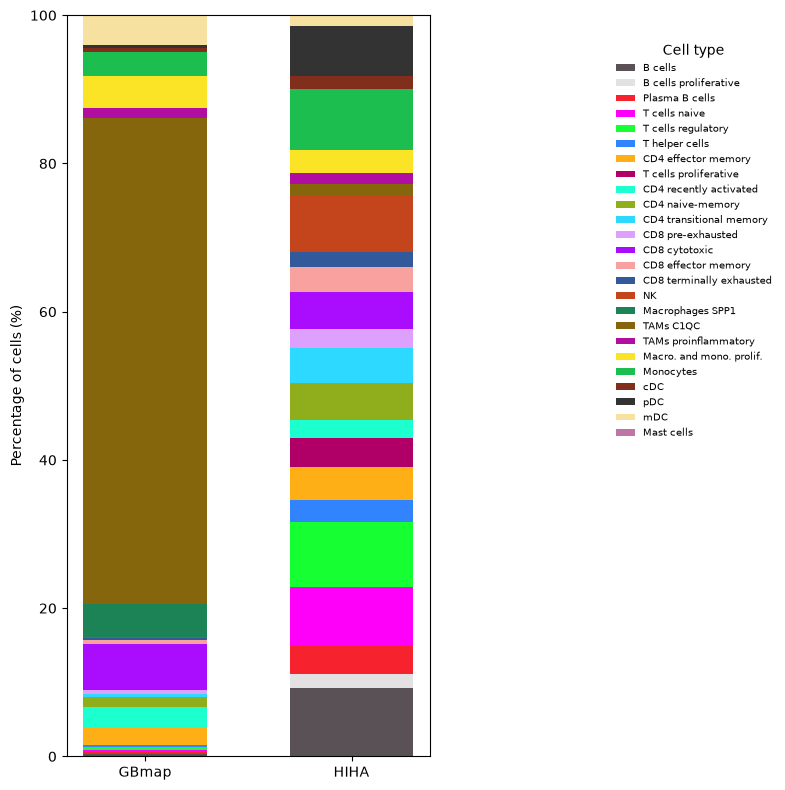

In [14]:
fig, ax = plt.subplots(figsize=(6, 8))
bottom = pd.Series(0, index=props_pct.columns)
for ct in celltype_palette.keys():
    ax.bar(props_pct.columns, props_pct.loc[ct], bottom=bottom,
           color=celltype_palette[ct], label=ct, width=0.6)
    bottom += props_pct.loc[ct]

ax.set_ylabel("Percentage of cells (%)", fontsize=10)
ax.set_xlabel("")
ax.set_ylim(0, 100)

handles = [Patch(facecolor=celltype_palette[ct], label=ct) for ct in celltype_palette.keys()]
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.02, 0.95),
           fontsize=7, title="Cell type", frameon=False)

plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.savefig(f"{OUT_DIR}/09_04_stacked_barplot_gbmap_vs_hiha.pdf", bbox_inches="tight", dpi=300)